
# Generalised NUTS / c-NUTS / GIST / c-GIST — prototype v0.1

This notebook is a **first unified implementation** based on the two earlier notebooks supplied in this conversation.

Current scope:

- arbitrary target supplied by `potential(x)` and `gradient(x)`;
- leapfrog dynamics only;
- identity mass matrix for now;
- regular NUTS;
- circularised NUTS (c-NUTS);
- regular GIST;
- circularised GIST (c-GIST);
- equal-probability ("uniform") NUTS candidate selection;
- Betancourt-style biased progressive selection for NUTS;
- GIST uniform tuning-variable selection;
- actual gradient-call accounting;
- trajectory span in leapfrog steps and physical integration time;
- acceptance / energy-error / ESS / ESS-per-second diagnostics.

## Important prototype limitation

The regular algorithms are general for any differentiable target.

The circularisation used in the earlier GIST notebook was a **local frozen scalar-frequency approximation**. For the radial examples there,
$$
\nabla U(x_0)=\kappa_0(x_0-\mu),
$$
so a local scalar frequency $\omega_0^2=\kappa_0$ is well-defined.

For a completely arbitrary non-radial target there is no unique scalar \(\omega_0\). Therefore this notebook makes the circularisation rule modular:

- `FrozenRadialCirculariser` reproduces the earlier frozen approximation;
- it can infer the scalar curvature from the radial projection of the gradient;
- or the user can pass an explicit `omega2_fn`;
- later we can replace this object by a more general Hessian-based/local metric construction without changing NUTS or GIST.

For GIST, `selection="biased_progressive"` is deliberately **not yet enabled**. The uniform GIST kernel has an explicit forward/reverse proposal ratio. A correct biased-progressive GIST version needs the corresponding forward/reverse selection probability to be defined carefully. The architecture below leaves a clean place to add it rather than silently implementing a kernel whose invariance is unclear.


In [1]:
import time
import warnings
from dataclasses import dataclass
from typing import Callable, Optional, Dict, Any, List, Tuple
import gc

import numpy as np
from scipy.special import logsumexp

from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
import pandas as pd

Array = np.ndarray


## 1. Target wrapper and exact gradient-call accounting

Every call to `target.gradient(x)` increments a counter. The counter is simply keeping track of how many times the sampler actually evaluates $U(x)$ and $\nabla U(x)$. Therefore, if we have a chain of samples in the form of a tree: $x_0, \cdots, x_N$, then the counter would store total $N+1$ potential $U(x_0), \cdots, U(x_N)$ and gradient of potential $\nabla U(x_0), \cdots, \nabla U(x_N)$ evaluation.

The leapfrog integrator stores the gradient at each state, so consecutive leapfrog steps reuse it and do not artificially double-count evaluations.


In [2]:
class Target:
    """
    Define a target distribution for sampling.
    The target density is proportiontional to exp(-potential(x)), where potential is a user-defined function.
    """

    def __init__(
        self,
        potential: Callable[[Array], float],
        gradient: Callable[[Array], Array],
        dimension: int,
        name: str = "target",
    ):
        """
        Attributes:
            potential (Callable[[Array], float]): Function to compute the potential energy.
            gradient (Callable[[Array], Array]): Function to compute the gradient of the potential energy.
            dimension (int): Dimensionality of the target distribution.
            name (str): Name of the target distribution.
        """
        if int(dimension) < 1:
            raise ValueError("dimension must be >= 1.")
        self.potential_fn = potential  # potential function
        self.gradient_fn = gradient  # grad of potential function
        self.dimension = int(dimension)
        self.name = str(name)
        self.gradient_calls = 0  # count of gradient calls, initialised to 0
        self.potential_calls = 0  # count of potential calls, initialised to 0

    def _vec(self, x):
        x = np.asarray(x, dtype=float)  # convert to numpy array
        if x.shape != (self.dimension,):
            raise ValueError(
                f"x must have shape ({self.dimension},), got {x.shape}."
            )  # check the shape consistency
        return x

    def potential(self, x) -> float:
        """Compute the potential energy at point x."""
        x = self._vec(x)
        self.potential_calls += 1  # increment the potential calls counter
        val = float(self.potential_fn(x))
        if not np.isfinite(val):
            raise FloatingPointError("Potential returned a non-finite value.")
        return val

    def gradient(self, x) -> Array:
        """Compute the gradient of the potential energy at point x."""
        x = self._vec(x)
        self.gradient_calls += 1  # increment the gradient calls counter
        g = np.asarray(self.gradient_fn(x), dtype=float)
        if g.shape != (self.dimension,):
            raise ValueError(
                f"gradient(x) must have shape ({self.dimension},), got {g.shape}."
            )  # check the gradient shape consistency
        if not np.all(np.isfinite(g)):
            raise FloatingPointError("Gradient returned a non-finite value.")  # check for non-finite values in the gradient
        return g

    def reset_counters(self):
        self.gradient_calls = 0
        self.potential_calls = 0

## 2. Leapfrog/Hamiltonian core

Carry the computation of leapfrog flow according to the leapfrog integrator as the symplectic integrator, for numerically solving the Hamilton equations.

In [3]:
@dataclass
class PhaseState:
    """Any state in the phase space of a Hamiltonian system."""
    x: Array  # position
    p: Array  # momentum
    grad: Array  # gradient of potential at x

    def copy(self):
        return PhaseState(self.x.copy(), self.p.copy(), self.grad.copy())


class Hamiltonian_System:
    """
    Identity-mass Hamiltonian system for version v0.1.
    A non-identity mass matrix can be implemented in future versions.
    """

    def __init__(self, target: Target, stepsize: float):
        if not np.isfinite(stepsize) or stepsize <= 0:
            raise ValueError("stepsize must be positive and finite.")
        self.target = target
        self.stepsize = float(stepsize)
        self.dimension = target.dimension

    def make_state(self, x, p) -> PhaseState:
        x = self.target._vec(x).copy()
        p = self.target._vec(p).copy()
        g = self.target.gradient(x)
        return PhaseState(x, p, g)

    # Solve the Hamiltonian dynamics using the leapfrog integrator.
    def leapfrog_step(self, state: PhaseState, direction: int = 1) -> PhaseState:
        if direction not in (-1, 1):  # check the direction, either forward (+1) or backward (-1)
            raise ValueError("direction must be -1 or +1.")

        h = direction * self.stepsize
        p_half = state.p - 0.5 * h * state.grad  # half-step momentum update
        x_new = state.x + h * p_half  # full-step position update, with unit mass assumption
        g_new = self.target.gradient(x_new)  # compute gradient at new position
        p_new = p_half - 0.5 * h * g_new  # half-step momentum update
        return PhaseState(x_new, p_new, g_new)

    def kinetic(self, p) -> float:
        """Return the kinetic energy for momentum p, assuming unit mass matrix."""
        p = np.asarray(p, dtype=float)
        return 0.5 * float(np.dot(p, p))

    def hamiltonian(self, state: PhaseState) -> float:
        """Compute the Hamiltonian (total energy) for a given phase state."""
        return self.target.potential(state.x) + self.kinetic(state.p)

    def log_weight(self, state: PhaseState) -> float:
        # canonical phase-space weight: exp(-H)
        # for numerical stability, we return the log weight (so later with logsumexp) instead of the weight itself
        # the log-weight is -H, where H is the Hamiltonian.
        return -self.hamiltonian(state)

## 3. Local circularisation

The local circularisation idea is based on locally circularising the leapfrog trajectory near a chosen starting point, where defaultly it is chosen as the initial position $x_0$.

Suppose the target is **radially symmetric** about the center $\mu$ (_this is a vital assumption, and we will separately check if the target is not symmetric by `radial_residual`, see more details below_), so the potential function can be written as
$$
U(x(t)) = \varphi(\|x(t)-\mu\|) \implies \nabla U(x(t)) = \frac{\varphi'(\|x(t)-\mu\|)}{\|x(t)-\mu\|}(x(t)-\mu) = \kappa(t)q(t), \qquad q(t) = x(t) - \mu
$$
where for the local circularisation, an important convention is to set $\kappa(t) = \kappa(0) = \kappa_0$, chosen as the initial circularisation. This means we shall carry the approximation
$$
\nabla U(x(t)) \approx \kappa_0 q(t)
$$
for all $t$ along with the original trajectory. A typical example can be $U(x) = \beta^{-1} \|x\|^\beta$, where we have $\mu=0$ and $\phi(x) = \beta^{-1}x^\beta$, then easily local circularisation gives the approximation $\nabla U(x(t)) \approx \kappa_0 x(t) = \|x_0\|^{\beta - 2}x(t)$.

We can compute $\kappa_0$ by:
$$
\nabla U(x(t)) = \kappa(t) q(t) \iff q(t)^T\nabla U(x(t)) = \kappa(t) q(t)^T q(t) \iff \kappa(t) = \frac{q(t)^T\nabla U(x(t))}{\|q(t)\|^2} \implies \kappa_0 = \frac{q_0^T\nabla U(x_0)}{\|q_0\|^2}
$$

For leapfrog stepsize $h$, since the global scale $\mu$ is constant, then $q(t+h) - q(t) = x(t+h) - x(t)$, meaning that it is cleaner to perform the derivation directly in centered $q$-coordinates. Applying local circularisation gives us
$$
\begin{aligned}
p\left(t + \frac{h}{2}\right) &= p(t) - \frac{h}{2}\kappa_0 q(t)\\
q(t + h) &= q(t) + hp\left(t + \frac{h}{2}\right) = \left(1 - \frac{h^2\kappa_0}{2}\right)q(t) + hp(t)\\
p(t + h) &= p\left(t + \frac{h}{2}\right) - \frac{h}{2}\kappa_0 q(t+h) = \left(1 - \frac{h^2 \kappa_0}{2}\right)p(t) - h\kappa_0 \left(1 - \frac{h^2 \kappa_0}{4}\right) q(t)
\end{aligned}
$$
this is similar with the isotropic Gaussian leapfrog flow, and then we can apply
$$
\gamma_0 = \sqrt{\kappa_0 \left(1-\frac{h^2\kappa_0}{4}\right)},
\qquad
Z_0=[q_0,\gamma_0^{-1}p_0]
$$

Then
$$
G=Z_0^T Z_0,\qquad
P=Z_0G^{-1}Z_0^T,
$$
and
$$
W = m Z_0G^{-2}Z_0^T+\eta(I-P).
$$

with free parameters $m$ and $\eta$, and their default values are 1 and 1 respectively. 

Note that the actual trajectory is still generated with the **true target gradient**, while only the U-turn geometry uses $W$ for local circularisation.

The quantity `radial_residual` measures how well the initial gradient $\nabla U(x_0)$ can be represented by a purely radial force of the form $\kappa_0 q_0$. Since $\kappa_0 q_0$ is the projection of the gradient onto the radial direction $q_0$, the residual

$$
\frac{\|\nabla U(x_0)-\kappa_0 q_0\|}{\|\nabla U(x_0)\|}
$$

gives the relative size of the non-radial component. **For an exactly radially symmetric target this quantity is zero, while a large value indicates that the scalar approximation $\nabla U(x_0)\approx \kappa_0 q_0$ may be inappropriate.** The code therefore compares this residual with a tolerance and either issues a warning or raises an error when the radial assumption is violated too strongly.

In [4]:
class Local_Circulariser:
    """
    Construct the local circularising metric W.

    Assume that near the starting position x0,

        grad U(x(t)) approx. kappa_0 * q(t),

    where

        q(t) = x(t) - center

    and kappa_0 is frozen at the initial point x0.

    The actual Hamiltonian trajectory is still generated using the true target gradient. 
    The frozen approximation is only used to construct W for the circularised U-turn criterion.
    """

    def __init__(
        self,
        center=None,
        m: float = 1.0,  # free parameter for circularised radius
        eta: float = 1.0,  # free parameter 
        rank_rtol: float = 1e-12,
        radial_rtol: float = 0.25,  # tolerance for checking radiality of the gradient
        strict_radial_check: bool = False,
    ):
        if m <= 0 or eta <= 0:
            raise ValueError("m and eta must be positive.")

        self.center = (
            None if center is None
            else np.asarray(center, dtype=float)
        )

        self.m = float(m)
        self.eta = float(eta)

        self.rank_rtol = float(rank_rtol)
        self.radial_rtol = float(radial_rtol)
        self.strict_radial_check = bool(strict_radial_check)

    def metric(
        self,
        x0: Array,
        p0: Array,
        grad0: Array,
        stepsize: float,
    ) -> Tuple[Array, Dict[str, Any]]:

        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)
        grad0 = np.asarray(grad0, dtype=float)

        d = x0.size

        # ------------------------------------------------------------
        # 1. Centred initial position q0 = x0 - mu
        # ------------------------------------------------------------

        center = np.zeros(d) if self.center is None else self.center

        if center.shape != (d,):
            raise ValueError(f"center must have shape ({d},).")

        q0 = x0 - center  # centered initial position

        q0_squared = float(np.dot(q0, q0))

        if q0_squared <= np.finfo(float).eps:
            raise ValueError(
                "Local circularisation is undefined/explosive at or too near the center."
            )

        # ------------------------------------------------------------
        # 2. Freeze the local radial coefficient kappa_0
        #
        #    grad U(x0) ≈ kappa_0 q0
        #
        # For an exactly radial target this gives the exact kappa_0.
        # Otherwise this is the least-squares scalar projection.
        # ------------------------------------------------------------

        kappa0 = float(np.dot(q0, grad0) / q0_squared)  # compute kappa0

        radial_residual = float(
            np.linalg.norm(grad0 - kappa0 * q0) / max(
                np.linalg.norm(grad0),
                np.finfo(float).eps  # for numerical stability only
            )
        )

        if radial_residual > self.radial_rtol:
            msg = (
                "Target gradient is not close to a radial scalar force at x0: "
                f"relative residual={radial_residual:.3g}."
            )

            if self.strict_radial_check:
                raise ValueError(msg)

            warnings.warn(msg, RuntimeWarning)

        if not np.isfinite(kappa0) or kappa0 <= 0:
            raise ValueError(
                "Local circularisation requires kappa_0 > 0; "
                f"obtained kappa_0 = {kappa0}."
            )

        # ------------------------------------------------------------
        # 3. Frozen leapfrog coefficient
        #
        # gamma_0^2 = kappa_0 * (1 - h^2 kappa_0 / 4)
        #
        # Leapfrog stability requires
        #
        #     1 - h^2 kappa_0 / 4 > 0.
        # ------------------------------------------------------------

        stability = 1.0 - stepsize**2 * kappa0 / 4.0

        if stability <= 0:
            raise ValueError(
                "Local circularisation approximation based on leapfrog integration is unstable: "
                "require stepsize^2 * kappa_0 < 4."
            )

        gamma0 = float(np.sqrt(kappa0 * stability))

        # ------------------------------------------------------------
        # 4. Construct Z0 = [q0, gamma_0^{-1} p0]
        # ------------------------------------------------------------

        Z0 = np.column_stack((q0, p0 / gamma0))

        # ------------------------------------------------------------
        # 5. Gram matrix G = Z0^T Z0
        # ------------------------------------------------------------

        G = Z0.T @ Z0

        eigvals, eigvecs = np.linalg.eigh(G)

        if (
            eigvals[-1] <= 0
            or
            eigvals[0] <= self.rank_rtol * eigvals[-1]
        ):
            raise np.linalg.LinAlgError(
                "Circularisation requires rank([q0, p0/gamma0]) = 2."
            )

        G_inv = eigvecs @ np.diag(1.0 / eigvals) @ eigvecs.T
        G_inv_squared = eigvecs @ np.diag(1.0 / eigvals**2) @ eigvecs.T

        # ------------------------------------------------------------
        # 6. Projection onto span(Z0), the trajectory space
        #
        # P = Z0 G^{-1} Z0^T
        # ------------------------------------------------------------

        P = Z0 @ G_inv @ Z0.T
        P = 0.5 * (P + P.T)  # Numerical symmetrisation

        # ------------------------------------------------------------
        # 7. Circularising metric - local circularisation matrix
        #
        # W = m Z0 G^{-2} Z0^T + eta (I - P)
        # ------------------------------------------------------------

        W = self.m * Z0 @ G_inv_squared @ Z0.T + self.eta * (np.eye(d) - P)
        W = 0.5 * (W + W.T)  # Numerical symmetrisation

        # ------------------------------------------------------------
        # 8. Diagnostic information
        # ------------------------------------------------------------

        info = {
            # "kappa0": kappa0,
            # "gamma0": gamma0,
            # "radial_residual": radial_residual,
            # "W": W,
            # "Z0": Z0,
            # "G": G,
            # "G_inv_squared": G_inv_squared,
            "circularisation_error": float(
                np.linalg.norm(
                    Z0.T @ W @ Z0
                    - self.m * np.eye(2)
                )
            ),  # Ideally: Z0^T W Z0 = m I_2, however for local circularisation this is not guaranteed to hold exactly, possibly with small errors.
        }

        return W, info

## 4. Shared U-turn criteria

Combine both the ordinary NUTS/GIST u-turn and circularised NUTS/GIST u-turn criteria. 

In [5]:
def uturn_valid(
    left: PhaseState,
    right: PhaseState,
    W: Optional[Array] = None
) -> bool:
    """
        Check whether a trajectory segment is still valid under the U-turn criterion.
    
        Let `left` and `right` denote the two endpoints of the current
        trajectory segment, and define
    
            dx = right.x - left.x.
    
        For regular NUTS, the trajectory is regarded as valid if
    
            dx^T left.p  >= 0
            dx^T right.p >= 0,
    
        up to a small numerical tolerance.
    
        If a circularising matrix W is supplied, the weighted U-turn
        criterion is used instead:
    
            dx^T W left.p  >= 0
            dx^T W right.p >= 0.
    
        Parameters
        ----------
        left : PhaseState
            Left endpoint of the trajectory segment.
    
        right : PhaseState
            Right endpoint of the trajectory segment.
    
        W : Array or None, optional
            Circularising matrix used in the weighted U-turn criterion.
            If None, the ordinary NUTS criterion is used.
    
        Returns
        -------
        bool
            True if both endpoint U-turn tests are satisfied, meaning that
            the trajectory segment is still valid; False if a U-turn has
            been detected.
        """
    
    dx = right.x - left.x
    if W is None:  # ordinary NUTS u-turn criterion
        a = float(np.dot(dx, left.p))
        b = float(np.dot(dx, right.p))
    else:  # circularised U-turn criterion
        a = float(np.dot(dx, W @ left.p))
        b = float(np.dot(dx, W @ right.p))
    return (a >= 0.0) and (b >= 0.0)


def one_sided_uturn_valid(
    initial: PhaseState,
    current: PhaseState,
    W: Optional[Array] = None
) -> bool:
    """
        Compute the one-sided U-turn score between an initial state and a current state along a trajectory.
        This is applied in GIST samplers.
    
        Let
    
            dx = current.x - initial.x.
    
        For the ordinary criterion, the score is
    
            dx^T current.p.
    
        For the circularised criterion, if a matrix W is supplied, the score
        becomes
    
            dx^T W current.p.
    
        A positive score indicates that the current momentum still points
        broadly away from the initial position, whereas a non-positive score    
        indicates a one-sided U-turn.
    
        Parameters
        ----------
        initial : PhaseState
            Initial phase-space state from which the trajectory is measured.
    
        current : PhaseState
            Current phase-space state along the trajectory.
    
        W : Array or None, optional
            Circularising matrix used in the weighted U-turn criterion.
            If None, the ordinary one-sided criterion is used.
    
        Returns
        -------
        bool
            True if the one-sided U-turn criterion is satisfied, False otherwise.
            indicates that a U-turn has been detected.
        """
    
    dx = current.x - initial.x
    if W is None:
        return float(np.dot(dx, current.p)) >= 0.0  # ordinary one-sided U-turn criterion
    return float(np.dot(dx, W @ current.p)) >= 0.0  # circularised one-sided U-turn criterion


## 5. Progressive candidate selection

**Progressive sampling**: the claim is only that the final candidate has the correct marginal distribution, not that every time we choose the old tree we independently resample from it.

For NUTS:

- `selection="uniform_progressive"` reproduces the equal-probability state selection. We split the currently constructed trajectory into two portions: the previously accepted portion with $n_{\mathrm{old}}$ states and the newly generated portion with $n_{\mathrm{new}}$ states. The new portion is chosen with probability

    $$
    \frac{n_{\mathrm{new}}}{n_{\mathrm{old}}+n_{\mathrm{new}}},
    $$

    after which one state is sampled uniformly from that portion; otherwise, the previously selected candidate is retained. Since the old candidate is already uniform over the old portion, this recursive update ensures that every state in the combined trajectory has equal probability

    $$
    \frac{1}{n_{\mathrm{old}}+n_{\mathrm{new}}}.
    $$


- `selection="biased_progressive"` uses canonical phase-space component weights $w=\sum \exp[-H(z)]$ and updates the active sample with probability
$$
\min(1,w_{\rm new}/w_{\rm old}).
$$

Because leapfrog does not conserve energy exactly, equal-probability selection is not in general the same as canonical weighting (_though I would not expect a huge difference_). The notebook keeps the equal-probability option because that is the requested baseline, while the biased-progressive option uses the Hamiltonian weights required by the progressive construction, and we shall add the discussion of BPS in later version.

In [6]:

def _sample_from_logweights(states, system, rng):
    """Use logsumexp to sample from a list of states with log-weights."""

    logw = np.array([system.log_weight(s) for s in states], dtype=float)
    logW = float(logsumexp(logw))  # compute the log of the sum of weights for numerical stability
    probs = np.exp(logw - logW)  # weight array for each state in the tree
    idx = int(rng.choice(len(states), p=probs))  # choose/sample the state by its log-weight
    return states[idx].copy(), logW


def _merge_candidate(
    old_candidate: PhaseState,
    old_states: List[PhaseState],  # a list of old states before the next step (doubling for NUTS, incrementation for GIST)
    new_states: List[PhaseState],  # a list of newly-generated states after the next step (doubling for NUTS, incrementation for GIST)
    system: Hamiltonian_System,
    rng: np.random.Generator,
    selection: str,
) -> PhaseState:
    if selection == "uniform_progressive":
        n_old = len(old_states)
        n_new = len(new_states)  # normally for the NUTS doubling process, we expect to see n_old == n_new
        if rng.uniform() < n_new / (n_old + n_new):
            return new_states[int(rng.integers(n_new))].copy()  # sample uniformly from new_states

        # Keep the existing candidate, which is already uniformly distributed over old_states by the previous progressive updates.
        # (we'll need recursive structure to ensure this, see the code for Section 6 addressing this issue)
        return old_candidate.copy()

    if selection == "biased_progressive":
        # old_candidate is already distributed according to the previous
        # component's canonical weights under repeated applications here.
        new_candidate, logW_new = _sample_from_logweights(
            new_states, system, rng
        )
        logW_old = float(logsumexp(
            [system.log_weight(s) for s in old_states]
        ))
        alpha = min(1.0, float(np.exp(min(0.0, logW_new - logW_old))))
        if rng.uniform() < alpha:
            return new_candidate  # sample the new state with log-weighted probability
        return old_candidate.copy()  # sample in the old state with log-weighted probability under recursive structure

    raise ValueError(
        "selection must be 'uniform_progressive' or 'biased_progressive'."
    )


## 6. General leapfrog NUTS / c-NUTS

In [7]:
class GeneralNUTS:
    def __init__(
        self,
        target: Target,
        stepsize: float,
        circulariser: Optional[Local_Circulariser] = None,  # if None, then ordinary NUTS/GIST
        selection: str = "uniform_progressive",  
        max_depth: int = 20,  # so we will always stop after 2^20 = 1048576 leapfrog steps, a very large number of steps for most practical applications
        seed: Optional[int] = None,
        # tol: float = 1e-12,
    ):
        if selection not in ("uniform_progressive", "biased_progressive"):
            raise ValueError("Unknown selection.")
        self.target = target
        self.system = Hamiltonian_System(target, stepsize)
        self.circulariser = circulariser
        self.selection = selection
        self.max_depth = int(max_depth)
        # self.tol = float(tol)
        self.rng = np.random.default_rng(seed)

    @property
    def circularised(self):
        return self.circulariser is not None

    def _block_valid(self, states: List[PhaseState], W) -> bool:
        # states has length 2^k as a dyadic block of depth k. Check all balanced binary sub-blocks,
        # matching the recursive logic of the earlier notebook.
        n = len(states)
        if n <= 1:
            return True  # meaning k=0, the single state is valid, and no U-turn check is needed for a single state, so return TRUE
        if not uturn_valid(states[0], states[-1], W):  # check the endpoints u-turn condition for the current block of states
            return False
        
        half = n // 2  # check for the smaller subtree: left and right halves of the block recursively, as dyadic blocks of depth k-1
        return (
            self._block_valid(states[:half], W)
            and self._block_valid(states[half:], W)
        )

    def transition(self, x_current: Array) -> Tuple[Array, Dict[str, Any]]:
        grad_before = self.target.gradient_calls
        
        # sample initial momentum from standard normal distribution, introduce mass matrix in future versions
        p0 = self.rng.normal(size=self.target.dimension)  
        z0 = self.system.make_state(x_current, p0)  # (z0.x, z0.p, z0.grad)

        W = None
        circ_info = None
        if self.circularised:
            W, circ_info = self.circulariser.metric(
                z0.x, z0.p, z0.grad, self.system.stepsize
            )  # extract the circularising metric W and diagnostic information from the circulariser

        # Initialise the retained states and other related terms with the initial state z0, 
        # used for recursive structure in the progressive selection of candidate states
        retained = [z0]
        candidate = z0.copy()
        left = z0.copy()
        right = z0.copy()
        left_index = 0
        right_index = 0

        successful_doublings = 0
        stop_reason = "max_depth"  # default stop reason if we reach the maximum depth without any U-turn or subtree failure
        failed_direction = None
        generated_states = 1  # initialise and count the initial state z0 as a generated state

        for depth in range(self.max_depth):
            direction = int(self.rng.choice([-1, 1]))  # randomly choose the direction for the next doubling step, either -1 (backward) or +1 (forward)
            block_size = 2**depth

            new_states = []
            cursor = left.copy() if direction == -1 else right.copy()

            for _ in range(block_size):
                # update the cursor state using the leapfrog integrator in the chosen direction
                cursor = self.system.leapfrog_step(cursor, direction)
                new_states.append(cursor.copy())

            generated_states += len(new_states)

            # Put states in increasing time/index order for U-turn checks.
            ordered_new = (
                list(reversed(new_states)) if direction == -1 else new_states
            )

            # stop the doubling process and tree expansion if u-turn is observed in the newly generated block of states
            # (for the old retained states, we have already checked its u-turn validity in the previous iterations)
            if not self._block_valid(ordered_new, W):
                stop_reason = "subtree_failed"
                failed_direction = direction
                break

            # update the leftmost and rightmost states if the new block is valid, 
            # and check the u-turn condition for the entire trajectory segment
            proposed_left = ordered_new[0] if direction == -1 else left
            proposed_right = right if direction == -1 else ordered_new[-1]
            if not uturn_valid(proposed_left, proposed_right, W):
                stop_reason = "full_tree_failed"
                failed_direction = direction
                break

            # Commit only a valid doubling.
            # The recursive structure is shown here within the for iteration loop, 
            # as each iteration will update the old_retained as the input old_candidate argument.

            # A simple progressive realisation ending on depth 2 can be illustrated as follows:
            # at depth 0, we have retained = [z0], candidate = z0
            # at depth 1, we have retained = [z0, z1], candidate = z1 (or z0, depending on the selection)
            # at depth 2, we have retained = [z0, z1, z2, z3], candidate = z2 (or z0, z1, z3, depending on the selection)   
            # according to the _merge_candidate, the probability to get each state after 2 doublings:
            #   - z0: 1/4 (choose z0 at depth 1 with prob. 1/2, then choose the old tree (give z0 directly) at depth 2 with prob. 1/2)
            #   - z1: 1/4 (choose z1 at depth 1 with prob. 1/2, then choose the old tree (give z1 directly) at depth 2 with prob. 1/2)
            #   - z2: 1/4 (choose the new tree at depth 2 with prob. 1/2, then choose z2 from the new tree with prob. 1/2)
            #   - z3: 1/4 (choose the new tree at depth 2 with prob. 1/2, then choose z3 from the new tree with prob. 1/2)
            # so the overall marginal distribution of the candidate is uniform over the 4 states, as expected.

            old_retained = retained
            candidate = _merge_candidate(
                candidate,
                old_retained,
                ordered_new,
                self.system,
                self.rng,
                self.selection,
            )

            if direction == -1:
                retained = ordered_new + retained  # update retained states in increasing time order
                left = ordered_new[0].copy()
                left_index -= block_size
            else:
                retained = retained + ordered_new  # update retained states in increasing time order
                right = ordered_new[-1].copy()
                right_index += block_size

            successful_doublings += 1

        grad_evals = self.target.gradient_calls - grad_before
        trajectory_steps = right_index - left_index # leapfrog integration steps taken in the trajectory

        info = {
            "algorithm": "c-NUTS" if self.circularised else "NUTS",
            "selection": self.selection,
            "successful_doublings": successful_doublings,
            "stop_reason": stop_reason,
            "failed_direction": failed_direction,
            "left_index": left_index,
            "right_index": right_index,
            "trajectory_steps": trajectory_steps,
            "trajectory_time": trajectory_steps * self.system.stepsize,
            #"retained_states": retained,  # states belonging to the valid NUTS tree after all successful doublings, eligible for progressive candidate selection

            # Number of states belonging to the valid retained tree after all successful doublings.
            # Do not store the complete PhaseState list, since doing so is
            # unnecessarily memory-expensive for long chains.
            "num_retained_states": len(retained),
            "generated_states": generated_states,  # this may be larger than the number of retained states, as some states may be discarded due to U-turns
            "generated_leapfrog_steps": generated_states - 1,
            "gradient_evals": grad_evals,
            "circularisation": circ_info,
        }
        return candidate.x.copy(), info

    def sample(
        self,
        initial_position,
        n_samples: int,
        burn_in: int = 0,
        thin: int = 1
    ):
        return run_chain(
            self, initial_position, n_samples, burn_in=burn_in, thin=thin
        )  # run_chain is a utility function to run the MCMC chain using the transition method of the sampler, see Section 8



## 7. General GIST / c-GIST

This retains the structure of the previous GIST notebook:

1. draw fresh momentum;
2. find forward first-U-turn index $\tau_1$;
3. choose $\alpha \sim\mathrm{Unif}\{1,\dots,\tau_1\}$;
4. propagate to the chosen point and reverse momentum;
5. compute reverse first-U-turn index $\tau_2$;
6. accept with
    $$
    \min\left\{1,\exp(-\Delta H)\frac{\tau_1}{\tau_2}\right\},
    $$
    provided $\alpha \le \tau_2$.

The implementation avoids recomputing the forward trajectory: the states generated while finding $\tau_1$ are reused.

For the complete left-to-right span, the reverse trajectory reaches index $L-\tau_2$ relative to the original point, while the forward endpoint is $\tau_1$. Therefore
$$
L_{\rm span}=\tau_1+\tau_2-L.
$$

In [8]:
class GeneralGIST:
    def __init__(
        self,
        target: Target,
        stepsize: float,
        circulariser: Optional[Local_Circulariser] = None,
        selection: str = "uniform_progressive",
        # we will always stop after 100000 leapfrog steps even if no one-sided U-turn is found, a very large number of steps for most practical applications
        max_stopping_steps: int = 100000,
        seed: Optional[int] = None,
    ):
        if selection not in ("uniform_progressive", "biased_progressive"):
            raise ValueError("Unknown selection.")
        self.target = target
        self.system = Hamiltonian_System(target, stepsize)
        self.circulariser = circulariser
        self.selection = selection
        self.max_stopping_steps = int(max_stopping_steps)
        self.rng = np.random.default_rng(seed)

    @property
    def circularised(self):
        return self.circulariser is not None

    def _stopping_trajectory(self, z0: PhaseState):
        W = None
        circ_info = None
        if self.circularised:
            W, circ_info = self.circulariser.metric(
                z0.x, z0.p, z0.grad, self.system.stepsize
            )

        states = [z0.copy()]  # initialise the list of states
        current = z0.copy()  # initialise the current state as the initial z0

        for n in range(1, self.max_stopping_steps + 1):
            current = self.system.leapfrog_step(current, +1)  # default forward direction
            states.append(current.copy())
            # Check the one-sided U-turn criterion between the initial state z0 and the current state
            if not one_sided_uturn_valid(z0, current, W):
                return n, states, circ_info  # stop the generation of trajectory when the one-sided U-turn criterion is violated (tau1)

        raise RuntimeError(
            "No one-sided U-turn found before max_stopping_steps."
        )

    def transition(self, x_current):
        if self.selection == "biased_progressive":
            raise NotImplementedError(
                "Biased-progressive GIST is intentionally deferred in v0.1. "
                "We need to define and verify its forward/reverse selection "
                "probabilities before inserting it into the GIST MH ratio."
            )

        grad_before = self.target.gradient_calls

        p0 = self.rng.normal(size=self.target.dimension)  # again identity mass so far in v0.1
        z0 = self.system.make_state(x_current, p0)

        tau1, forward_states, circ_info1 = self._stopping_trajectory(z0)

        alpha = int(self.rng.integers(1, tau1 + 1))  # randomly choose alpha
        z_alpha = forward_states[alpha].copy()  # store the state at the randomly chosen alpha-th step along the forward trajectory

        proposed = PhaseState(
            z_alpha.x.copy(),
            -z_alpha.p.copy(),  # reverse the momentum/velocity for the reverse trajectory
            z_alpha.grad.copy(),
        )

        tau2, reverse_states, circ_info2 = self._stopping_trajectory(proposed)

        H0 = self.system.hamiltonian(z0)  # initial Hamiltonian energy
        H_alpha = self.system.hamiltonian(z_alpha)  # Hamiltonian energy at the randomly chosen alpha-th step
        delta_H = H_alpha - H0  # change in Hamiltonian energy from the initial state to the randomly chosen alpha-th state

        if alpha > tau2:
            accept_prob = 0.0
        else:
            log_ratio = -delta_H + np.log(tau1) - np.log(tau2)
            accept_prob = 1.0 if log_ratio >= 0 else float(np.exp(log_ratio))

        accepted = bool(self.rng.uniform() < accept_prob)  # acceptance prob.
        x_next = z_alpha.x.copy() if accepted else z0.x.copy()

        # Forward endpoint is tau1; reverse endpoint is L - tau2.
        left_index = alpha - tau2
        right_index = tau1
        span_steps = right_index - left_index

        grad_evals = self.target.gradient_calls - grad_before

        info = {
            "algorithm": "c-GIST" if self.circularised else "GIST",
            "selection": self.selection,
            "accepted": accepted,
            "acceptance_probability": accept_prob,
            "energy_error": float(delta_H),
            "tau1_steps": tau1,
            "tau2_steps": tau2,
            "alpha_steps": alpha,
            "tau1_time": tau1 * self.system.stepsize,
            "tau2_time": tau2 * self.system.stepsize,
            "alpha_time": alpha * self.system.stepsize,
            "left_index": left_index,
            "right_index": right_index,
            "trajectory_steps": span_steps,
            "trajectory_time": span_steps * self.system.stepsize,
            "gradient_evals": grad_evals,
            "circularisation_forward_info": circ_info1,
            "circularisation_reverse_info": circ_info2,
        }
        return x_next, info

    def sample(
        self,
        initial_position,
        n_samples: int,
        burn_in: int = 0,
        thin: int = 1
    ):
        return run_chain(
            self, initial_position, n_samples, burn_in=burn_in, thin=thin
        )

## 8. Common chain runner and diagnostics

For counting the processing time, we shall record the CPU processing time, see more in https://stackoverflow.com/questions/52222002/what-is-the-difference-between-time-perf-counter-and-time-process-time and official documentation https://docs.python.org/3/library/time.html#module-time.

In [9]:
def ess_1d(x, max_lag=10000):
    """
    Estimate the effective sample size (ESS) and integrated
    autocorrelation time (IACT) of a scalar MCMC chain.

    The autocorrelation function is computed using
    statsmodels.tsa.stattools.acf with FFT acceleration.

    Geyer's initial positive sequence and initial monotone sequence
    are applied to the paired autocorrelations

        P_0 = rho_0 + rho_1,
        P_1 = rho_2 + rho_3,
        ...

    The integrated autocorrelation time is estimated as

        tau = -1 + 2 * sum_j P_j,

    and the effective sample size is

        ESS = n / tau.

    Parameters
    ----------
    x : array-like
        Scalar MCMC chain, which should be a component if the MCMC output is multivariate vector.

    max_lag : int, optional
        Maximum lag used for estimating the autocorrelation
        function. The actual maximum is restricted to n - 1.

    Returns
    -------
    ess : float
        Estimated effective sample size.

    iact : float
        Estimated integrated autocorrelation time.
    """

    x = np.asarray(x, dtype=float)
    n = len(x)

    max_lag = min(int(max_lag), n - 1)

    # Compute the autocorrelation function, rho[0] = 1.
    rho = acf(
        x,
        nlags=max_lag,
        fft=True,
        adjusted=False,
    )

    # --------------------------------------------------------
    # Geyer's initial positive sequence
    #
    # Pair the autocorrelations as
    #
    #     P_0 = rho_0 + rho_1
    #     P_1 = rho_2 + rho_3
    #     ...
    #
    # and stop at the first non-positive pair.
    # --------------------------------------------------------

    pair_sums = []
    k = 0

    while 2 * k + 1 < len(rho):

        pair = rho[2 * k] + rho[2 * k + 1]

        # Initial positive sequence: break the loop if the first non-positive pair is encountered.
        if pair <= 0:
            break

        pair_sums.append(pair)

        k += 1

    pair_sums = np.asarray(pair_sums, dtype=float)

    if len(pair_sums) == 0:
        return np.nan, np.nan
    
    # --------------------------------------------------------
    # Geyer's initial monotone sequence
    #
    # Enforce
    #
    #     P_k <= P_{k-1}.
    # --------------------------------------------------------
    for k in range(1, len(pair_sums)):

        pair_sums[k] = min(
            pair_sums[k],
            pair_sums[k - 1],
        )

    # Integrated autocorrelation time:
    #
    #     tau = 1 + 2 * sum_{k >= 1} rho_k
    #
    # which can be written using the paired sums as
    #
    #     tau = -1 + 2 * sum_j P_j.
    #
    iact = -1.0 + 2.0 * np.sum(pair_sums)
    ess = float(n / iact)

    return ess, iact


def acceptance_dataframe(infos):
    """
    Convert step-by-step acceptance diagnostics into a pandas DataFrame.

    This is mainly applicable to GIST/c-GIST, where every transition
    has an explicit Metropolis-Hastings acceptance probability and
    accept/reject decision.

    Parameters
    ----------
    infos : list of dict
        Diagnostic dictionaries returned by sampler.transition().

    Returns
    -------
    df : pandas.DataFrame
        One row for each transition for which acceptance diagnostics
        are available.
    """

    rows = []

    for iteration, info in enumerate(infos, start=1):

        # NUTS/c-NUTS do not have the same explicit final
        # accept/reject step, so skip entries without these fields.
        if (
            "accepted" not in info
            or "acceptance_probability" not in info
        ):
            continue

        rows.append({
            "iteration": iteration,
            "accepted": bool(info["accepted"]),
            "acceptance_probability": float(
                info["acceptance_probability"]
            ),
            "energy_error": float(
                info.get("energy_error", np.nan)
            ),
            "tau1_steps": info.get("tau1_steps", np.nan),
            "tau2_steps": info.get("tau2_steps", np.nan),
            "alpha_steps": info.get("alpha_steps", np.nan),
            "trajectory_steps": info.get("trajectory_steps", np.nan),
        })

    return pd.DataFrame(rows)


def chain_summary(samples, infos, elapsed, acf_max_lag=20):
    """
    Summarise the sampling efficiency and computational diagnostics
    of a completed MCMC chain.

    Parameters
    ----------
    samples : array-like, shape (n_samples, dimension)
        Retained MCMC samples.

    infos : list of dict
        Diagnostic information associated with the retained MCMC transitions.

    elapsed : float
        Total elapsed time of the chain run.

    acf_max_lag : int, optional
            Maximum ACF lag. This is DIFFERENT with the max_lag of ESS!

    Returns
    -------
    out : dict
        Dictionary containing ACF, ESS, IACT, computational cost,
        trajectory length and, where available, acceptance statistics.
    """

    samples = np.asarray(samples, dtype=float)

    if samples.ndim != 2:
        raise ValueError(
            "samples must have shape (n_samples, dimension)."
        )

    d = samples.shape[1]

    # --------------------------------------------------------
    # Effective sample size (ESS) and integrated autocorrelation time (IACT)
    # --------------------------------------------------------

    rho = [
        acf(samples[:, j],
            nlags=min(acf_max_lag, len(samples) - 1),
            fft=True,
            adjusted=False)
        for j in range(d)
    ]

    ess_results = [
        ess_1d(samples[:, j], max_lag=10000)
        for j in range(d)
    ]  # compute and store the ESS and IACT for each coordinate of the multivariate samples

    ess = np.array(
        [result[0] for result in ess_results],
        dtype=float,
    )  # store the ESS values for each coordinate in an array

    iact = np.array(
        [result[1] for result in ess_results],
        dtype=float,
    )  # store the IACT values for each coordinate in an array

    # --------------------------------------------------------
    # Computational diagnostics
    # --------------------------------------------------------

    grad = np.array(
        [
            info.get("gradient_evals", np.nan)
            for info in infos
        ],
        dtype=float,
    )

    steps = np.array(
        [
            info.get("trajectory_steps", np.nan)
            for info in infos
        ],
        dtype=float,
    )

    times = np.array(
        [
            info.get("trajectory_time", np.nan)
            for info in infos
        ],
        dtype=float,
    )

    total_gradient_evals = np.nansum(grad)

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    out = {
        # ============ ACF and Effective sample size ============
        "acf": rho,
        "ess": ess,
        "min_ess": float(np.min(ess)),
        "mean_ess": float(np.mean(ess)),  # mean ESS across all coordinates

        # ============ Integrated autocorrelation time ============
        "iact": iact,
        "max_iact": float(np.max(iact)),
        "mean_iact": float(np.mean(iact)),  # mean IACT across all coordinates

        # ============ ESS per unit time, measuring overall efficiency ============
        "ess_per_second": (
            ess / elapsed
            if elapsed > 0
            else np.full(d, np.nan)
        ),
        "min_ess_per_second": (
            float(np.min(ess / elapsed))
            if elapsed > 0
            else np.nan
        ),
        "elapsed_seconds": float(elapsed),  # total elapsed time of the chain run

        # ============ Gradient evaluations ============
        "gradient_evals": grad,
        "mean_gradient_evals": float(np.nanmean(grad)),
        "total_gradient_evals": int(total_gradient_evals),  # total number of gradient evaluations across all retained samples

        # ============ Trajectory length ============
        "trajectory_steps": steps,
        "mean_trajectory_steps": float(np.nanmean(steps)),
        "trajectory_time": times,
        "mean_trajectory_time": float(np.nanmean(times))
    }

    # --------------------------------------------------------
    # Acceptance diagnostics
    #
    # These are available for samplers such as GIST/c-GIST
    # which explicitly return an accept/reject decision.
    # We expect to see a higher acceptance rate for circularised samplers than ordinary samplers.
    # --------------------------------------------------------

    if len(infos) > 0 and all("accepted" in info for info in infos):

        accepted = np.array(
            [
                info["accepted"]
                for info in infos
            ],
            dtype=bool,
        )  # store the acceptance decisions for each retained sample in a boolean array

        acceptance_probabilities = np.array(
            [
                info["acceptance_probability"]
                for info in infos
            ],
            dtype=float,
        )  # store the acceptance probabilities for each retained sample in a float array

        out["acceptance_rate"] = float(
            np.mean(accepted)
        )

        out["mean_acceptance_probability"] = float(
            np.mean(acceptance_probabilities)
        )

    return out


def run_chain(
    sampler,
    initial_position,
    n_samples: int,
    burn_in: int = 0,  # default cold-start setting: no burn-in
    thin: int = 1,  # default setting: no thinning
):
    """
    Run an MCMC chain using one of the implemented samplers.

    Parameters
    ----------
    sampler
        NUTS, c-NUTS, GIST or c-GIST sampler.

    initial_position : array-like
        Initial position of the chain.

    n_samples : int
        Number of retained samples.

    burn_in : int, optional
        Number of initial MCMC iterations discarded before
        samples are retained.

    thin : int, optional
        Keep one sample every `thin` MCMC iterations after burn-in.

    Returns
    -------
    result : dict
        Dictionary containing samples, transition diagnostics, acceptance tables,
        summary statistics, elapsed time and the sampler object.
    """

    if n_samples < 1:
        raise ValueError("n_samples must be >= 1.")
    if burn_in < 0 or thin < 1:
        raise ValueError("Require burn_in >= 0 and thin >= 1.")

    # Initialise the current position.
    current = np.asarray(initial_position, dtype=float).copy()
    d = sampler.target.dimension

    if current.shape != (d,):
        raise ValueError(f"initial_position must have shape ({d},).")

    # Total number of MCMC transitions required to obtain
    # n_samples retained samples after burn-in and thinning.
    total = burn_in + n_samples * thin

    generated_samples = np.empty((n_samples, d))  # initialise
    all_infos = []  # info for all generated samples, including those discarded during burn-in and thinning
    kept_infos = []  # info for samples after burn-in and thinning

    # Reset the target evaluation counters before starting the chain.
    sampler.target.reset_counters()

    # We shall apply the CPU process time to measure the elapsed time for the entire chain run, either ordinary or circularised NUTS/GIST
    # t0 = time.perf_counter()
    t0 = time.process_time()  
    k = 0  # index used for storing retained samples

    for iteration in range(total):
        current, info = sampler.transition(current)
        # Store diagnostics for every MCMC transition.
        all_infos.append(info)

        # Store samples and diagnostics after burn-in and thinning.
        if iteration >= burn_in and (iteration - burn_in) % thin == 0:
            generated_samples[k] = current  # store the current sample in the generated samples array
            kept_infos.append(info)
            k += 1  # update

    # Record the elapsed time for the entire chain run, either ordinary or circularised NUTS/GIST
    # elapsed = time.perf_counter() - t0
    elapsed = time.process_time() - t0
    summary = chain_summary(generated_samples, kept_infos, elapsed = elapsed)

    # --------------------------------------------------------
    # Acceptance tables
    #
    # For GIST/c-GIST these contain one row per transition.
    # For NUTS/c-NUTS they will simply be empty DataFrames.
    # --------------------------------------------------------
    
    acceptance_table = acceptance_dataframe(
        kept_infos
    )  # record the retained samples' acceptance diagnostics in a pandas DataFrame, which is mainly applicable to GIST/c-GIST
    
    # all_acceptance_table = acceptance_dataframe(
    #     all_infos
    # )

    return {
        "samples": generated_samples,
        "infos": kept_infos,  # diagnostics corresponding to retained samples
        "all_infos": all_infos,  # diagnostics corresponding to all generated samples, including those discarded during burn-in and thinning
        "summary": summary,
        "acceptance_table": acceptance_table,
        "elapsed_seconds": elapsed,
        "sampler": sampler,
    }

In [10]:
def repeated_acceptance_experiment(
    sampler,
    initial_position,
    n_repeats: int = 1000,
):
    """
    Estimate acceptance behaviour at a fixed starting position
    by repeatedly performing independent sampler transitions from
    exactly the same initial position.

    Each repetition uses new random momentum and other sampler
    randomness, but the position is reset to initial_position
    before every repetition.

    This is mainly intended for GIST/c-GIST.

    Parameters
    ----------
    sampler
        GIST or c-GIST sampler.

    initial_position : array-like
        Fixed starting position used for every repetition.

    n_repeats : int, optional
        Number of repeated transitions.

    Returns
    -------
    result : dict
        Dictionary containing the complete acceptance table,
        empirical acceptance probability and the average of the
        transition-level Metropolis-Hastings acceptance probabilities.
    """

    if n_repeats < 1:
        raise ValueError(
            "n_repeats must be >= 1."
        )

    x0 = np.asarray(
        initial_position,
        dtype=float,
    ).copy()

    d = sampler.target.dimension

    if x0.shape != (d,):
        raise ValueError(
            f"initial_position must have shape ({d},)."
        )

    infos = []

    for _ in range(n_repeats):

        # Always start from exactly the same position, which is x0.
        _, info = sampler.transition(
            x0.copy()
        )

        if (
            "accepted" not in info
            or "acceptance_probability" not in info
        ):
            raise ValueError(
                "repeated_acceptance_experiment requires a sampler "
                "with explicit acceptance diagnostics, such as "
                "GIST or c-GIST."
            )

        infos.append(info)

    table = acceptance_dataframe(
        infos
    )

    # Empirical acceptance probability:
    #
    #     number accepted / number of repeated trials.
    empirical_acceptance_probability = float(
        table["accepted"].mean()
    )

    # Monte Carlo estimate of the expectation of the
    # transition-level MH acceptance probability.
    mean_acceptance_probability = float(
        table["acceptance_probability"].mean()
    )

    return {
        "acceptance_table": table,
        "empirical_acceptance_probability":
            empirical_acceptance_probability,
        "mean_acceptance_probability":
            mean_acceptance_probability,
        "n_repeats": int(n_repeats),
        "initial_position": x0,
    }


---

## 9. Convenience constructor: one public function

This is the first version of the unified interface we discussed.


In [11]:
def make_sampler(
    *,
    potential,
    gradient,
    dimension,
    algorithm="nuts",
    stepsize=0.1,
    selection="uniform_progressive",
    center=None,
    m=1.0,
    eta=1.0,
    max_depth=20,
    max_stopping_steps=100000,
    seed=None,
    strict_radial_check=False,
):

    if selection not in ("uniform_progressive", "biased_progressive"):
        raise ValueError("Unknown selection.")
    
    target = Target(
        potential=potential,
        gradient=gradient,
        dimension=dimension,
    )  # define the target distribution using the provided potential and gradient functions, along with the specified dimension

    key = algorithm.lower().replace("_", "-")  # normalize the algorithm name to lowercase and replace underscores with hyphens for consistency
    circular = key in ("c-nuts", "cnuts", "c-gist", "cgist")  # check if the algorithm is circularised NUTS or GIST

    circulariser = None
    if circular:  # once we apply the circularised algorithms...
        circulariser = Local_Circulariser(
            center=center,
            m=m,
            eta=eta,
            strict_radial_check=strict_radial_check,
        )

    if key in ("nuts", "c-nuts", "cnuts"):  # carry the NUTS/c-NUTS algorithm
        return GeneralNUTS(
            target=target,
            stepsize=stepsize,
            circulariser=circulariser,
            selection=selection,
            max_depth=max_depth,
            seed=seed,
        )

    if key in ("gist", "c-gist", "cgist"):  # carry the GIST/c-GIST algorithm
        return GeneralGIST(
            target=target,
            stepsize=stepsize,
            circulariser=circulariser,
            selection=selection,
            max_stopping_steps=max_stopping_steps,
            seed=seed,
        )

    raise ValueError(
        "algorithm must be one of 'nuts', 'c-nuts', 'gist', 'c-gist'."
    )

## 10. Smoke test: 2D standard Gaussian

In [ ]:
def make_test_samplers(target_potential, target_grad, stepsize):
    """Define the samplers to be tested in the repeated realisations of the sampling experiment."""
    return {
        "NUTS": make_sampler(
            potential=target_potential,
            gradient=target_grad,
            dimension=2,
            algorithm="nuts",
            stepsize=stepsize,
            selection="uniform_progressive",
            seed=1,
        ),

        "c-NUTS": make_sampler(
            potential=target_potential,
            gradient=target_grad,
            dimension=2,
            algorithm="c-nuts",
            stepsize=stepsize,
            selection="uniform_progressive",
            center=np.zeros(2),
            seed=2,
        ),

        "GIST": make_sampler(
            potential=target_potential,
            gradient=target_grad,
            dimension=2,
            algorithm="gist",
            stepsize=stepsize,
            seed=3,
        ),

        "c-GIST": make_sampler(
            potential=target_potential,
            gradient=target_grad,
            dimension=2,
            algorithm="c-gist",
            stepsize=stepsize,
            center=np.zeros(2),
            seed=4,
        ),
    }


def run_sampler_comparison(
    target_potential,
    target_grad,
    x0,
    stepsize,
    n_samples=10000,
    n_realisations=5,
    plot_acf=True,
    acf_coordinate=0,
):
    """
    Run repeated comparisons of NUTS, c-NUTS, GIST and c-GIST,
    print summary diagnostics, and optionally plot the ACF comparison
    for a selected coordinate.

    Parameters
    ----------
    target_potential : callable
        Potential function U(x).

    target_grad : callable
        Gradient of the potential, grad U(x).

    x0 : array-like
        Initial position of the chain.

    stepsize : float
        Leapfrog step size.

    n_samples : int, optional
        Number of samples per chain.

    n_realisations : int, optional
        Number of repeated realisations.

    plot_acf : bool, optional
        Whether to plot the ACF comparison after all realisations.

    acf_coordinate : int, optional
        Coordinate whose ACF is plotted. 
        Default is 0, i.e. the first coordinate.

    Returns
    -------
    acf_values : dict
        Dictionary containing the ACF of the selected coordinate
        for each sampler from the final realisation.

    summaries : dict
        Dictionary containing the summary output for each sampler
        from the final realisation.
    """

    summaries = {}
    acf_values = {}

    for i in range(n_realisations):

        print()
        print("=" * 105)
        print(
            f"REALISATION {i + 1} / {n_realisations}"
        )
        print("=" * 105)

        print(
            f"{'Sampler':<10}"
            f"{'Mean ESS':>12}"
            f"{'CPU time (s)':>16}"
            f"{'Min ESS/CPU s':>18}"
            f"{'Mean grad evals':>18}"
            f"{'Mean traj. steps':>19}"
        )

        print("-" * 105)

        # Re-create samplers so that each realisation uses
        # exactly the same controlled seeds.
        samplers = make_test_samplers(
            target_potential=target_potential,
            target_grad=target_grad,
            stepsize=stepsize,
        )

        for name, sampler in samplers.items():

            result = sampler.sample(
                x0,
                n_samples=n_samples,
            )

            s = result["summary"]

            # Save summary
            summaries[name] = s

            # Save ACF of chosen coordinate
            acf_values[name] = s["acf"][acf_coordinate]

            print(
                f"{name:<10}"
                f"{s['mean_ess']:>12.1f}"
                f"{s['elapsed_seconds']:>16.3f}"
                f"{s['min_ess_per_second']:>18.1f}"
                f"{s['mean_gradient_evals']:>18.1f}"
                f"{s['mean_trajectory_steps']:>19.1f}"
            )

            del result
            gc.collect()

        # --------------------------------------------------------
        # Integrated ACF comparison
        # RUN THIS ONLY WHEN THE SEEDS FOR EACH SAMPLER ARE RANDOM!
        # --------------------------------------------------------
        
        # if plot_acf:
        
        #     plt.figure(figsize=(8, 5))
        
        #     for name, values in acf_values.items():
        
        #         lags = np.arange(len(values))
        
        #         plt.plot(
        #             lags,
        #             values,
        #             marker="o",
        #             markersize=3,
        #             label=name,
        #         )
        
        #     plt.axhline(
        #         0.0,
        #         linestyle="--",
        #         linewidth=1,
        #     )
        
        #     plt.xticks(lags)
        #     plt.xlabel("Lag")
        #     plt.ylabel("ACF")
        
        #     plt.title(
        #         f"ACF comparison for coordinate "
        #         f"{acf_coordinate + 1}"
        #     )
        
        #     plt.legend()
        #     plt.grid(alpha=0.25)
        #     plt.tight_layout()
        #     plt.show()

        print("=" * 105)

    # --------------------------------------------------------
    # Integrated ACF comparison
    # --------------------------------------------------------

    if plot_acf:

        plt.figure(figsize=(8, 5))

        for name, values in acf_values.items():

            lags = np.arange(len(values))

            plt.plot(
                lags,
                values,
                marker="o",
                markersize=3,
                label=name,
            )

        plt.axhline(
            0.0,
            linestyle="--",
            linewidth=1,
        )

        plt.xticks(lags)

        plt.xlabel("Lag")
        plt.ylabel("ACF")

        plt.title(
            f"ACF comparison for coordinate "
            f"{acf_coordinate + 1}"
            f"realisation {i+1}"
        )

        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

    return acf_values, summaries


REALISATION 1 / 5
Sampler       Mean ESS    CPU time (s)     Min ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            1131.0           3.250             332.7              28.3               13.1
c-NUTS          4293.7           8.922             464.1              64.0               31.0
GIST            5126.2           4.609            1094.4              52.0               38.1
c-GIST         10601.9           7.797            1342.8              65.0               47.6

REALISATION 2 / 5
Sampler       Mean ESS    CPU time (s)     Min ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            1131.0           3.188             339.3              28.3               13.1
c-NUTS          4293.7           8.828             469.0              64.0               31.

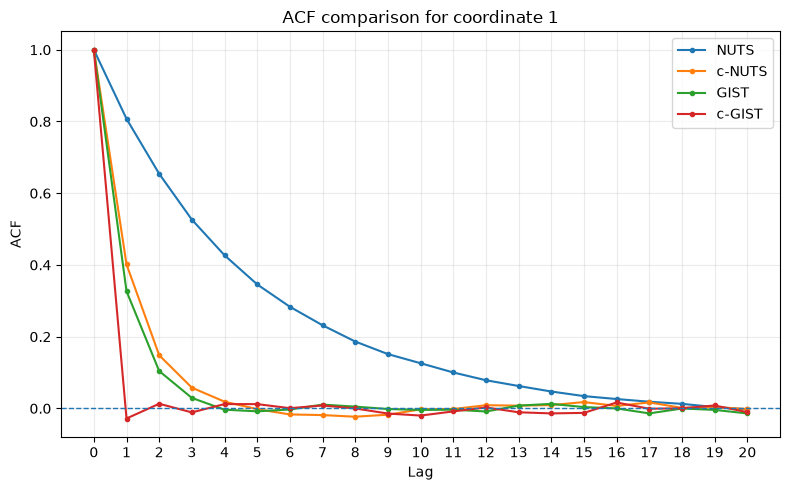

In [13]:
def gaussian_potential(x):
    return 0.5 * np.dot(x, x)

def gaussian_grad(x):
    return x

x0 = np.array([3.0, 4.0])
stepsize = 0.099  # stepsize choice seems important - for 0.099 we shall have good result!
n_samples = 10000
n_realisations = 5  # number of repeated realisations of the sampling experiment to check for consistency and stability of the results

acf_values, summaries = run_sampler_comparison(target_potential=gaussian_potential,
                       target_grad=gaussian_grad,
                       x0=x0,
                       stepsize=stepsize,
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0)

---

## 11. Biased progressive NUTS example

In [14]:

# bps_nuts = make_sampler(
#     potential=gaussian_potential,
#     gradient=gaussian_grad,
#     dimension=2,
#     algorithm="nuts",
    
#     stepsize=0.15,
#     selection="biased_progressive",
#     seed=10,
# )

# bps_result = bps_nuts.sample(
#     initial_position=np.array([2.0, -1.0]),
#     n_samples=500,
#     burn_in=50,
# )

# print(bps_result["summary"])


## 12. Non-Gaussian radial example


REALISATION 1 / 5
Sampler       Mean ESS    CPU time (s)     Min ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            1272.4           3.688             337.6              28.2               13.1
c-NUTS          1400.7           6.078             212.1              34.3               16.2
GIST            5121.8           5.172             956.6              49.1               35.9
c-GIST         10172.4           8.562            1134.2              60.3               44.1

REALISATION 2 / 5
Sampler       Mean ESS    CPU time (s)     Min ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            1272.4           3.672             339.0              28.2               13.1
c-NUTS          1400.7           5.969             216.0              34.3               16.

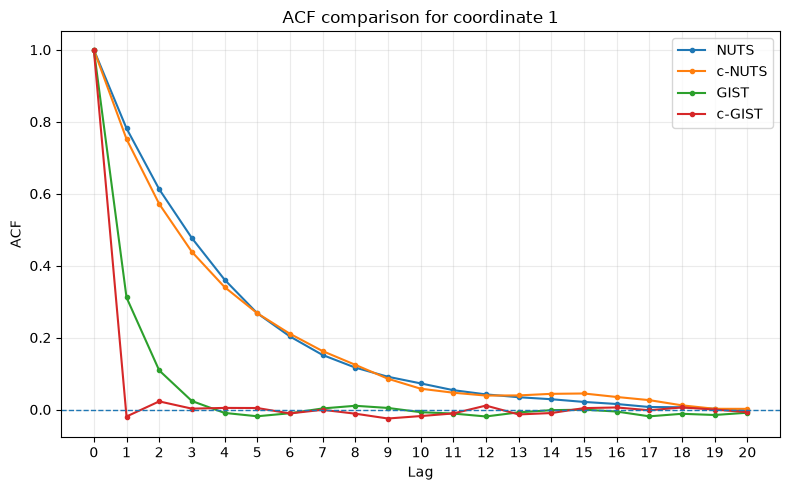

In [15]:
beta = 1.5  # beta is a number that between 1 and 2

def beta1_potential(x):
    r2 = np.dot(x, x)

    return (1.0 + r2) ** (beta / 2.0)


def beta1_grad(x):
    r2 = np.dot(x, x)

    return (
        beta
        * (1.0 + r2) ** (beta / 2.0 - 1.0)
        * x
    )

x0 = np.array([3.0, 4.0])
stepsize = 0.099  # stepsize choice seems important - for 0.099 we shall have good result!
n_samples = 10000
n_realisations = 5  # number of repeated realisations of the sampling experiment to check for consistency and stability of the results

acf_values, summaries = run_sampler_comparison(target_potential=beta1_potential,
                       target_grad=beta1_grad,
                       x0=x0,
                       stepsize=stepsize,
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0)




For
$$
U(x)=\frac{1}{\beta}\|x\|^\beta,
\qquad
\nabla U(x)=\|x\|^{\beta-2}x,
$$
the inferred frozen scalar coefficient is exactly
$$
\kappa_0=\|x_0\|^{\beta-2},
$$
so this reproduces the local frozen construction from the previous GIST notebook.



REALISATION 1 / 5
Sampler       Mean ESS    CPU time (s)     Min ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            1336.0           4.359             282.1              34.7               16.4
c-NUTS          2406.5           8.094             294.1              49.9               23.9
GIST            4970.9           6.219             759.6              58.8               43.2
c-GIST          9153.1           9.969             888.9              70.3               51.7

REALISATION 2 / 5
Sampler       Mean ESS    CPU time (s)     Min ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            1336.0           4.578             268.6              34.7               16.4
c-NUTS          2406.5           9.438             252.2              49.9               23.

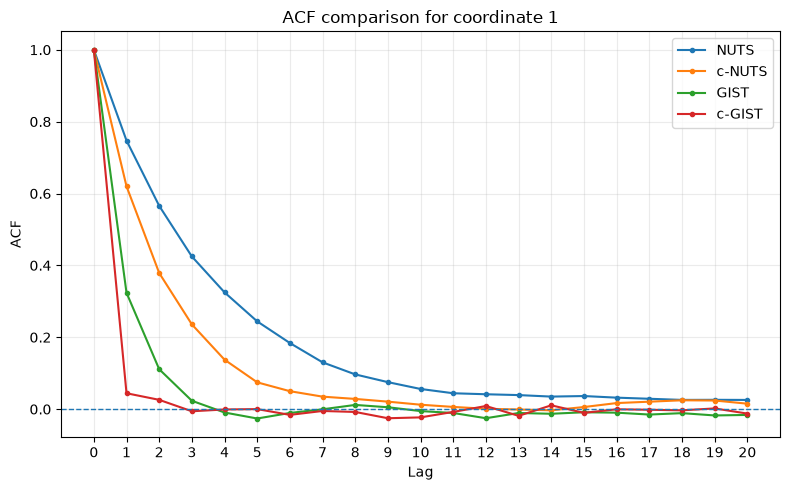

In [16]:

beta = 1.5  # beta is a number that between 1 and 2

def beta2_potential(x):
    r2 = np.dot(x, x)
    return (r2 ** (beta / 2.0)) / beta

def beta2_grad(x):
    r2 = np.dot(x, x)
    if r2 == 0:
        return np.zeros_like(x)
    return (r2 ** (beta / 2.0 - 1.0)) * x

x0 = np.array([3.0, 4.0])
stepsize = 0.099  # stepsize choice seems important - for 0.099 we shall have good result!
n_samples = 10000
n_realisations = 5  # number of repeated realisations of the sampling experiment to check for consistency and stability of the results

acf_values, summaries = run_sampler_comparison(target_potential=beta2_potential,
                       target_grad=beta2_grad,
                       x0=x0,
                       stepsize=stepsize,
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0)


## 13. Next implementation steps

The most important next extensions are:

1. verify each transition against the two previous notebooks on Gaussian/radial targets;
2. add the exact GIST biased-progressive proposal probability and its reverse probability;
3. decide the general non-radial local circularisation rule (likely a separate circulariser object rather than hard-coding it into the sampler);
4. add optional diagonal/dense mass matrices;
5. add dual-averaging step-size adaptation during warm-up;
6. add ACF plotting and a compact comparison table across all four samplers;
7. later add a PosteriorDB/BridgeStan target backend.
